In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ML libraries
import xgboost as xgb
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Add project root to path (adjust as needed for your setup)
project_root = Path().cwd().parent.parent.resolve()
sys.path.insert(0, str(project_root))

# Import your utilities (adjust import paths as needed)
try:
    from src.utils.file_paths import file_paths, TISSUE_DIMENSIONS
    from src.utils.pr_test import charpoly, charpoly_vectorized

    print("Successfully imported utilities")
except ImportError as e:
    print(f"Could not import utilities: {e}")
    print("You may need to adjust the import paths")

# Try to use faster BLAS if available
try:
    import mkl
    mkl.set_num_threads(1)  # Prevent oversubscription in parallel operations
except ImportError:
    pass

/Users/chaechae/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Successfully imported utilities


In [2]:

# Try to use faster BLAS if available
try:
    import mkl
    mkl.set_num_threads(1)  # Prevent oversubscription in parallel operations
except ImportError:
    pass

In [3]:
class PixelMLP(nn.Module):
    """MLP model for pixel classification - matches saved model with BatchNorm"""
    def __init__(self, input_dim=16, hidden_dims=[128, 64, 32], dropout_rate=0.2):
        super(PixelMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            # BatchNorm layer
            layers.append(nn.BatchNorm1d(hidden_dim))
            # ReLU activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        # Use 'net' to match saved model
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [4]:
def charpoly(M, verbose=False):
    """
    Original charpoly function for single matrix - now uses vectorized version
    
    Args:
        M: Single 4x4 matrix
        verbose: Whether to print coefficient values
        
    Returns:
        Boolean indicating physical realizability
    """
    # Convert single matrix to batch format and use vectorized version
    M_batch = M.reshape(1, 4, 4)
    result = charpoly_vectorized(M_batch, verbose=verbose)
    return result[0]  # Return single boolean value


In [5]:
def load_sample(tissue_type, sample_name):
    """
    Load a single non-combined sample file (H,W,16)
    
    Args:
        tissue_type: Type of tissue ('brain', 'cervix', 'afmmm')
        sample_name: Name of the sample file
        
    Returns:
        arr: Loaded array (H, W, 16)
        dims: Dimensions info
    """
    print(f"Loading {tissue_type} sample: {sample_name}")

    # Set up file paths based on tissue type
    if tissue_type.lower() == 'brain':
        test_dir = file_paths.brain_test_path
        dims = TISSUE_DIMENSIONS['brain']
    elif tissue_type.lower() == 'cervix':
        test_dir = file_paths.cervix_test_path
        dims = TISSUE_DIMENSIONS['cervix']
    elif tissue_type.lower() == 'afmmm':
        test_dir = file_paths.afmmm_test_path
        dims = TISSUE_DIMENSIONS['afmmm']
    elif tissue_type.lower() == 'simulated':
        test_dir = file_paths.simulated_test_path
        dims = TISSUE_DIMENSIONS['simulated']
    else:
        raise ValueError(f"Invalid tissue type: {tissue_type}")

    # Find the sample file
    sample_path = test_dir / sample_name
    if not sample_path.exists():
        # Try to find it in subdirectories
        found_files = list(test_dir.glob(f'**/{sample_name}'))
        if found_files:
            sample_path = found_files[0]
        else:
            raise FileNotFoundError(f"Sample not found: {sample_name} in {test_dir}")

    # Load the sample
    arr = np.load(sample_path)
    expected_shape = (dims['num_rows'], dims['num_cols'], 16)

    print(f"Loaded sample shape: {arr.shape}")
    print(f"Expected shape: {expected_shape}")

    if arr.shape != expected_shape:
        print(f"Warning: Shape mismatch!")

    return arr, dims


In [6]:
def compute_ground_truth_pr_mask(mueller_matrix, batch_size=50000):
    """
    OPTIMIZED: Compute ground truth PR mask using vectorized charpoly method
    
    Args:
        mueller_matrix: Mueller matrix array (H, W, 16)
        batch_size: Number of pixels to process per batch (much larger now)
        
    Returns:
        pr_mask: Boolean mask (H, W) indicating physically realizable pixels
        timing_info: Timing information
    """
    print(f"Computing OPTIMIZED ground truth PR test using vectorized charpoly (batch size: {batch_size:,})...")
    
    H, W, _ = mueller_matrix.shape
    total_pixels = H * W
    
    # Pre-reshape to (N, 4, 4) for batch processing - eliminates per-pixel reshaping
    mueller_matrices = mueller_matrix.reshape(-1, 16).reshape(-1, 4, 4)
    pr_results = np.zeros(total_pixels, dtype=bool)
    
    # Use high precision timing
    start_time = time.perf_counter()
    
    # Process in batches using VECTORIZED operations - no more nested loops!
    for i in range(0, total_pixels, batch_size):
        end_idx = min(i + batch_size, total_pixels)
        batch_matrices = mueller_matrices[i:end_idx]
        
        # Vectorized PR test - processes entire batch at once
        batch_results = charpoly_vectorized(batch_matrices)
        pr_results[i:end_idx] = batch_results
    
    end_time = time.perf_counter()
    gt_time_s = end_time - start_time
    gt_time_ms = gt_time_s * 1000
    
    # Reshape back to (H, W)
    pr_mask = pr_results.reshape(H, W)
    pr_pixels = np.sum(pr_mask)
    
    print(f"OPTIMIZED ground truth PR test completed in {gt_time_ms:.2f} ms ({gt_time_s:.3f}s)")
    print(f"GT PR pixels: {pr_pixels:,} ({pr_pixels/total_pixels*100:.2f}%)")
    
    timing_info = {
        'time': gt_time_s,
        'time_ms': gt_time_ms,
        'samples_per_second': total_pixels / gt_time_s,
        'samples_per_ms': total_pixels / gt_time_ms,
        'total_pixels': total_pixels,
        'pr_pixels': int(pr_pixels),
        'batch_size': batch_size
    }
    
    return pr_mask, timing_info

In [7]:
def predict_mlp(model, X, batch_size=4096, device=None):
    """Generate predictions using MLP model with batching"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            preds.append(probs)
    return np.concatenate(preds)

In [8]:
def load_xgboost_model():
    """
    Load the trained XGBoost model
    
    Returns:
        model: Loaded XGBoost model
    """
    print("Loading XGBoost model...")
    
    model_path = file_paths.model_save_path / 'pixel_xgb.json'
    
    if not model_path.exists():
        raise FileNotFoundError(f"XGBoost model not found at: {model_path}")
    
    model = xgb.Booster()
    model.load_model(str(model_path))
    
    print(f"Model loaded successfully from: {model_path}")
    return model

In [9]:
def load_and_predict_ml(mueller_matrix, use_model='xgb', batch_size=None, threshold=0.5):
    """
    MAXIMALLY OPTIMIZED: Load ML model and make predictions with all possible optimizations
    
    Args:
        mueller_matrix: Mueller matrix array (H, W, 16)
        use_model: ML model to use ('xgb', 'mlp', 'cat')
        batch_size: Batch size for processing
        threshold: Probability threshold for classification
        
    Returns:
        ml_mask: Predicted PR mask (H, W)
        timing_info: Timing information
    """
    H, W, _ = mueller_matrix.shape
    total_pixels = H * W
    
    # Extract features (all 16 elements) - minimize memory operations
    X_flat = mueller_matrix.reshape(-1, 16)
    
    # Device for PyTorch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if use_model.lower() == 'xgb':
        print(f"Making MAXIMALLY OPTIMIZED XGBoost predictions (single batch: {total_pixels:,}, threshold: {threshold})...")
        print(f"Using all 16 Mueller matrix elements for XGBoost")
        
        # Create DMatrix with optimized settings - this is the key optimization
        dmat = xgb.DMatrix(X_flat, nthread=1)  # Single thread to avoid overhead
        
        # Load model
        xgb_model = xgb.Booster()
        xgb_model.load_model(str(file_paths.model_save_path / 'pixel_xgb.json'))
        
        start_time = time.perf_counter()
        # Single prediction call - this is the bottleneck we can't avoid
        probs = xgb_model.predict(dmat)
        end_time = time.perf_counter()
        
        # Direct boolean conversion and reshape - avoid intermediate arrays
        ml_mask = (probs > threshold).reshape(H, W)
        
    elif use_model.lower() == 'mlp':
        print(f"Making OPTIMIZED MLP predictions (batch_size: {batch_size if batch_size else 'default'}, threshold: {threshold})...")
        print(f"Using all 16 Mueller matrix elements")
        
        # MLP model
        mlp = PixelMLP().to(device)
        mlp_path = file_paths.model_save_path / 'best_pixel_mlp.pth'
        mlp.load_state_dict(torch.load(mlp_path, map_location=device))
        mlp.eval()
        
        # Use provided batch_size or default for MLP
        mlp_batch_size = batch_size if batch_size is not None else 4096
        
        start_time = time.perf_counter()
        probs = predict_mlp(mlp, X_flat, batch_size=mlp_batch_size, device=device)
        end_time = time.perf_counter()
        
        # Apply threshold and reshape
        ml_mask = (probs > threshold).reshape(H, W)
        
    elif use_model.lower() == 'cat':
        print(f"Making OPTIMIZED CatBoost predictions (full dataset, threshold: {threshold})...")
        print(f"Using all 16 Mueller matrix elements")
        
        # CatBoost
        cat_model = CatBoostClassifier()
        cat_model.load_model(str(file_paths.model_save_path / 'pixel_catboost.cbm'))
        
        start_time = time.perf_counter()
        # Get predictions - CatBoost processes full dataset efficiently
        probs = cat_model.predict_proba(X_flat)[:, 1]
        end_time = time.perf_counter()
        
        # Apply threshold and reshape
        ml_mask = (probs > threshold).reshape(H, W)
        
    else:
        raise ValueError(f"Invalid model type: {use_model}")
    
    ml_time_s = end_time - start_time
    ml_time_ms = ml_time_s * 1000
    ml_pixels = np.sum(ml_mask)

    print(f"MAXIMALLY OPTIMIZED {use_model.upper()} completed in {ml_time_ms:.2f} ms ({ml_time_s:.4f}s)")
    print(f"ML PR pixels: {ml_pixels:,} ({ml_pixels / total_pixels * 100:.2f}%)")

    timing_info = {
        'model': use_model.upper(),
        'time': ml_time_s,
        'time_ms': ml_time_ms,
        'samples_per_second': total_pixels / ml_time_s,
        'samples_per_ms': total_pixels / ml_time_ms,
        'total_pixels': total_pixels,
        'pr_pixels': int(ml_pixels),
        'batch_size': batch_size if use_model.lower() == 'mlp' else total_pixels,
        'threshold': threshold
    }

    return ml_mask, timing_info

In [10]:
def compare_methods(gt_mask, ml_mask, model_name):
    """
    Compare ground truth and ML predictions
    
    Args:
        gt_mask: Ground truth PR mask (H, W)
        ml_mask: ML predicted PR mask (H, W)
        model_name: Name of the ML model
        
    Returns:
        comparison_metrics: Dictionary with comparison metrics
    """
    print(f"Comparing {model_name} with ground truth...")

    # Calculate confusion matrix elements
    true_positives = np.sum(gt_mask & ml_mask)
    false_positives = np.sum(~gt_mask & ml_mask)
    false_negatives = np.sum(gt_mask & ~ml_mask)
    true_negatives = np.sum(~gt_mask & ~ml_mask)

    total_pixels = gt_mask.size

    # Calculate metrics
    accuracy = (true_positives + true_negatives) / total_pixels
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Agreement statistics
    agreement = np.sum(gt_mask == ml_mask) / total_pixels

    # Jaccard index (Intersection over Union)
    intersection = np.sum(gt_mask & ml_mask)
    union = np.sum(gt_mask | ml_mask)
    jaccard = intersection / union if union > 0 else 0

    comparison_metrics = {
        'model': model_name,
        'total_pixels': total_pixels,
        'gt_pr_pixels': int(np.sum(gt_mask)),
        'ml_pr_pixels': int(np.sum(ml_mask)),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'agreement': agreement,
        'jaccard_index': jaccard
    }

    print("Comparison Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Agreement: {agreement:.4f} ({agreement * 100:.2f}%)")
    print(f"  Jaccard Index: {jaccard:.4f}")

    return comparison_metrics

In [11]:
def visualize_multi_model_comparison(gt_mask, ml_masks, model_names, sample_name):
    """
    Visualize comparison between ground truth and multiple ML models
    
    Args:
        gt_mask: Ground truth PR mask (H, W)
        ml_masks: List of ML predicted PR masks
        model_names: List of model names
        sample_name: Name of the sample
    """
    print("Creating multi-model comparison visualization...")
    
    n_models = len(ml_masks)
    fig, axes = plt.subplots(2, n_models + 1, figsize=(5 * (n_models + 1), 10))
    
    if n_models == 1:
        axes = axes.reshape(2, -1)
    
    # Ground truth (top row, first column)
    axes[0, 0].imshow(gt_mask, cmap='viridis')
    axes[0, 0].set_title('Ground Truth\n(Vectorized charpoly)')
    axes[0, 0].axis('off')
    
    # ML models (top row, remaining columns)
    for i, (ml_mask, model_name) in enumerate(zip(ml_masks, model_names)):
        axes[0, i + 1].imshow(ml_mask, cmap='viridis')
        axes[0, i + 1].set_title(f'{model_name}\nPrediction')
        axes[0, i + 1].axis('off')
    
    # Difference maps (bottom row)
    axes[1, 0].axis('off')  # Empty space below ground truth
    
    for i, (ml_mask, model_name) in enumerate(zip(ml_masks, model_names)):
        diff = gt_mask.astype(int) - ml_mask.astype(int)
        im = axes[1, i + 1].imshow(diff, cmap='coolwarm', vmin=-1, vmax=1)
        axes[1, i + 1].set_title(f'{model_name}\nDifference (GT - ML)')
        axes[1, i + 1].axis('off')
        plt.colorbar(im, ax=axes[1, i + 1], shrink=0.6)
    
    plt.suptitle(f'Multi-Model PR Test Comparison: {sample_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [12]:
def run_multi_model_comparison(models=['xgb', 'mlp', 'cat'], gt_batch_size=50000, ml_batch_size=100000, threshold=0.5):
    """
    OPTIMIZED: Run comparison between ground truth and multiple ML models with large batch processing
    
    Args:
        models: List of models to test ('xgb', 'mlp', 'cat')
        gt_batch_size: Batch size for ground truth processing
        ml_batch_size: Batch size for ML model processing (applies to MLP, others process all at once)
        threshold: Probability threshold for ML classification
    """
    print("=" * 80)
    print("OPTIMIZED MULTI-MODEL COMPARISON: XGBoost vs MLP vs CatBoost vs Ground Truth")
    print("=" * 80)

    try:
        # 1. Load the non-combined sample (H,W,16)
        mueller_matrix, dims = load_sample(TISSUE_TYPE, SAMPLE_NAME)

        print(f"Sample: {SAMPLE_NAME}")
        print(f"Shape: {mueller_matrix.shape}")
        print(f"Total Pixels: {mueller_matrix.shape[0] * mueller_matrix.shape[1]:,}")
        print(f"Models to test: {', '.join([m.upper() for m in models])}")
        print(f"Ground Truth Batch Size: {gt_batch_size:,}")
        print(f"ML Batch Size: {ml_batch_size:,} (MLP only, others process full dataset)")
        print(f"Threshold: {threshold}")
        print("-" * 80)

        # 2. Compute OPTIMIZED ground truth PR mask
        gt_mask, gt_timing = compute_ground_truth_pr_mask(mueller_matrix, batch_size=gt_batch_size)

        # 3. Test each ML model with OPTIMIZED batch processing
        ml_results = {}
        ml_masks = []
        model_names = []
        
        for model in models:
            print(f"\n--- Testing OPTIMIZED {model.upper()} ---")
            try:
                # Use optimized batch size for each model type
                if model.lower() == 'mlp':
                    # MLP benefits from large batch sizes
                    ml_mask, ml_timing = load_and_predict_ml(mueller_matrix, use_model=model, 
                                                           batch_size=ml_batch_size, threshold=threshold)
                else:
                    # XGBoost and CatBoost process entire dataset at once (most efficient)
                    ml_mask, ml_timing = load_and_predict_ml(mueller_matrix, use_model=model, 
                                                           batch_size=None, threshold=threshold)
                
                comparison_metrics = compare_methods(gt_mask, ml_mask, model.upper())
                
                ml_results[model] = {
                    'timing': ml_timing,
                    'comparison': comparison_metrics,
                    'mask': ml_mask
                }
                
                ml_masks.append(ml_mask)
                model_names.append(model.upper())
                
            except Exception as e:
                print(f"Error testing {model.upper()}: {e}")
                import traceback
                traceback.print_exc()
                continue

        # 4. Visualize results if we have successful models
        if ml_masks:
            visualize_multi_model_comparison(gt_mask, ml_masks, model_names, SAMPLE_NAME)

        # 5. Print OPTIMIZED comprehensive summary
        print("\n" + "=" * 80)
        print("OPTIMIZED MULTI-MODEL PERFORMANCE SUMMARY")
        print("=" * 80)

        print(f"VECTORIZED Ground Truth (charpoly):")
        print(f"  Time: {gt_timing['time_ms']:.2f} ms ({gt_timing['time']:.3f}s)")
        print(f"  Speed: {gt_timing['samples_per_second']:,.1f} samples/s")
        print(f"  Speed: {gt_timing['samples_per_ms']:,.2f} samples/ms")
        print(f"  Batch Size: {gt_timing['batch_size']:,}")
        print(f"  PR Pixels: {gt_timing['pr_pixels']:,}")

        for model, results in ml_results.items():
            timing = results['timing']
            comparison = results['comparison']
            speed_ratio_sps = timing['samples_per_second'] / gt_timing['samples_per_second']
            speed_ratio_time = gt_timing['time_ms'] / timing['time_ms']
            
            print(f"\nOptimized {model.upper()}:")
            print(f"  Time: {timing['time_ms']:.2f} ms ({timing['time']:.3f}s)")
            print(f"  Speed: {timing['samples_per_second']:,.1f} samples/s")
            print(f"  Speed: {timing['samples_per_ms']:,.2f} samples/ms")
            print(f"  Speed Ratio (ML/GT): {speed_ratio_sps:.1f}x")
            print(f"  Time Ratio (GT/ML): {speed_ratio_time:.1f}x")
            if timing['batch_size']:
                print(f"  Batch Size: {timing['batch_size']:,}")
            else:
                print(f"  Batch Size: Full dataset (most efficient)")
            print(f"  PR Pixels: {timing['pr_pixels']:,}")
            print(f"  Accuracy: {comparison['accuracy']:.4f}")
            print(f"  F1 Score: {comparison['f1_score']:.4f}")
            print(f"  Precision: {comparison['precision']:.4f}")
            print(f"  Recall: {comparison['recall']:.4f}")

        # Find fastest model and best accuracy
        if ml_results:
            fastest_model = max(ml_results.keys(), key=lambda x: ml_results[x]['timing']['samples_per_second'])
            best_accuracy = max(ml_results.keys(), key=lambda x: ml_results[x]['comparison']['accuracy'])
            best_f1 = max(ml_results.keys(), key=lambda x: ml_results[x]['comparison']['f1_score'])
            
            print(f"\nOPTIMIZED SUMMARY:")
            print(f"  Fastest Model: {fastest_model.upper()} ({ml_results[fastest_model]['timing']['samples_per_second']:,.0f} samples/s)")
            print(f"  Most Accurate: {best_accuracy.upper()} (Accuracy: {ml_results[best_accuracy]['comparison']['accuracy']:.4f})")
            print(f"  Best F1 Score: {best_f1.upper()} (F1: {ml_results[best_f1]['comparison']['f1_score']:.4f})")
            
            # Overall performance comparison
            gt_time = gt_timing['time_ms']
            ml_times = [ml_results[model]['timing']['time_ms'] for model in ml_results.keys()]
            fastest_ml_time = min(ml_times)
            fastest_ml_model = min(ml_results.keys(), key=lambda x: ml_results[x]['timing']['time_ms'])
            
            print(f"  Overall Fastest: {fastest_ml_model.upper()} vs Ground Truth = {gt_time/fastest_ml_time:.1f}x speedup")

        return {
            'ground_truth': gt_timing,
            'ml_results': ml_results,
            'config': {
                'gt_batch_size': gt_batch_size,
                'ml_batch_size': ml_batch_size,
                'threshold': threshold
            }
        }

    except Exception as e:
        print(f"Error during optimized multi-model comparison: {e}")
        import traceback
        traceback.print_exc()
        return None

In [13]:
def run_model_batch_analysis(models=['xgb', 'mlp', 'cat'], 
                            batch_sizes=[1000, 5000, 10000, 50000, 100000], 
                            num_runs=3, threshold=0.5):
    """
    Analyze batch size performance across multiple models
    
    Args:
        models: List of models to test
        batch_sizes: List of batch sizes to test
        num_runs: Number of runs per configuration
        threshold: ML threshold
    """
    print("="*80)
    print("MULTI-MODEL BATCH SIZE ANALYSIS")
    print("="*80)
    
    try:
        mueller_matrix, _ = load_sample(TISSUE_TYPE, SAMPLE_NAME)
        total_pixels = mueller_matrix.shape[0] * mueller_matrix.shape[1]
        
        print(f"Sample: {SAMPLE_NAME}")
        print(f"Total pixels: {total_pixels:,}")
        print(f"Models: {', '.join([m.upper() for m in models])}")
        print(f"Number of runs per configuration: {num_runs}")
        print("-" * 80)
        
        results = {model: [] for model in models}
        
        for model in models:
            print(f"\n--- Testing {model.upper()} ---")
            
            for batch_size in batch_sizes:
                if model == 'mlp':
                    # MLP uses internal batching, so we pass the batch_size parameter
                    print(f"Testing {model.upper()} with batch size: {batch_size:,}", end=" ")
                else:
                    # XGB and CatBoost don't use batch processing in the same way
                    print(f"Testing {model.upper()} (batch size N/A for this model)", end=" ")
                
                run_times = []
                run_speeds = []
                
                for run in range(num_runs):
                    try:
                        if model == 'mlp':
                            _, timing = load_and_predict_ml(mueller_matrix, use_model=model, 
                                                          batch_size=batch_size, threshold=threshold)
                        else:
                            _, timing = load_and_predict_ml(mueller_matrix, use_model=model, 
                                                          threshold=threshold)
                        
                        run_times.append(timing['time_ms'])
                        run_speeds.append(timing['samples_per_second'])
                        print(".", end="")
                    except Exception as e:
                        print(f"Error in run {run+1}: {e}")
                        continue
                
                if run_times:  # Only record if we have successful runs
                    avg_time_ms = np.mean(run_times)
                    std_time_ms = np.std(run_times)
                    avg_speed_s = np.mean(run_speeds)
                    
                    results[model].append({
                        'batch_size': batch_size if model == 'mlp' else 'N/A',
                        'avg_time_ms': avg_time_ms,
                        'std_time_ms': std_time_ms,
                        'avg_speed_s': avg_speed_s,
                        'min_time_ms': min(run_times),
                        'max_time_ms': max(run_times)
                    })
                    
                    print(f" | Avg: {avg_time_ms:.1f}±{std_time_ms:.1f}ms, Speed: {avg_speed_s:,.0f} samples/s")
                else:
                    print(" | Failed")
        
        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        colors = ['blue', 'red', 'green', 'orange', 'purple']
        
        for i, model in enumerate(models):
            if results[model]:  # Only plot if we have data
                model_results = results[model]
                times = [r['avg_time_ms'] for r in model_results]
                speeds = [r['avg_speed_s'] for r in model_results]
                std_times = [r['std_time_ms'] for r in model_results]
                
                if model == 'mlp':
                    x_values = batch_sizes[:len(times)]
                    axes[0].errorbar(x_values, times, yerr=std_times, 
                                   fmt=f'{colors[i % len(colors)]}-o', label=model.upper(), 
                                   linewidth=2, markersize=6)
                    axes[1].plot(x_values, speeds, f'{colors[i % len(colors)]}-o', 
                               label=model.upper(), linewidth=2, markersize=6)
                else:
                    # For non-batched models, show as horizontal line
                    axes[0].axhline(y=times[0], color=colors[i % len(colors)], 
                                  linestyle='--', label=f'{model.upper()} (no batching)', linewidth=2)
                    axes[1].axhline(y=speeds[0], color=colors[i % len(colors)], 
                                  linestyle='--', label=f'{model.upper()} (no batching)', linewidth=2)
        
        axes[0].set_xlabel('Batch Size (MLP only)')
        axes[0].set_ylabel('Processing Time (ms)')
        axes[0].set_title('Processing Time vs Batch Size')
        axes[0].set_xscale('log')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        
        axes[1].set_xlabel('Batch Size (MLP only)')
        axes[1].set_ylabel('Speed (samples/second)')
        axes[1].set_title('Processing Speed vs Batch Size')
        axes[1].set_xscale('log')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
        
        plt.suptitle(f'Multi-Model Performance Analysis - {SAMPLE_NAME}', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print("\n" + "="*80)
        print("BATCH ANALYSIS SUMMARY")
        print("="*80)
        
        for model in models:
            if results[model]:
                model_results = results[model]
                best_idx = np.argmin([r['avg_time_ms'] for r in model_results])
                best_result = model_results[best_idx]
                
                print(f"{model.upper()}:")
                print(f"  Best Time: {best_result['avg_time_ms']:.1f} ± {best_result['std_time_ms']:.1f} ms")
                print(f"  Best Speed: {best_result['avg_speed_s']:,.0f} samples/s")
                if model == 'mlp':
                    print(f"  Best Batch Size: {best_result['batch_size']:,}")
                else:
                    print(f"  Batch Size: Not applicable")
        
        return results
        
    except Exception as e:
        print(f"Error during batch analysis: {e}")
        import traceback
        traceback.print_exc()
        return None


OPTIMIZED Multi-Model Mueller Matrix Runtime Test
Comparing XGBoost, MLP, and CatBoost with ground truth PR test
Using large batch sizes for maximum performance
OPTIMIZED MULTI-MODEL COMPARISON: XGBoost vs MLP vs CatBoost vs Ground Truth
Loading simulated sample: mm_300um_raw.npy
Loaded sample shape: (100, 100, 16)
Expected shape: (100, 100, 16)
Sample: mm_300um_raw.npy
Shape: (100, 100, 16)
Total Pixels: 10,000
Models to test: XGB, MLP, CAT
Ground Truth Batch Size: 100,000
ML Batch Size: 100,000 (MLP only, others process full dataset)
Threshold: 0.5
--------------------------------------------------------------------------------
Computing OPTIMIZED ground truth PR test using vectorized charpoly (batch size: 100,000)...
OPTIMIZED ground truth PR test completed in 4.61 ms (0.005s)
GT PR pixels: 1,976 (19.76%)

--- Testing OPTIMIZED XGB ---
Making MAXIMALLY OPTIMIZED XGBoost predictions (single batch: 10,000, threshold: 0.5)...
Using all 16 Mueller matrix elements for XGBoost
MAXIMALLY O

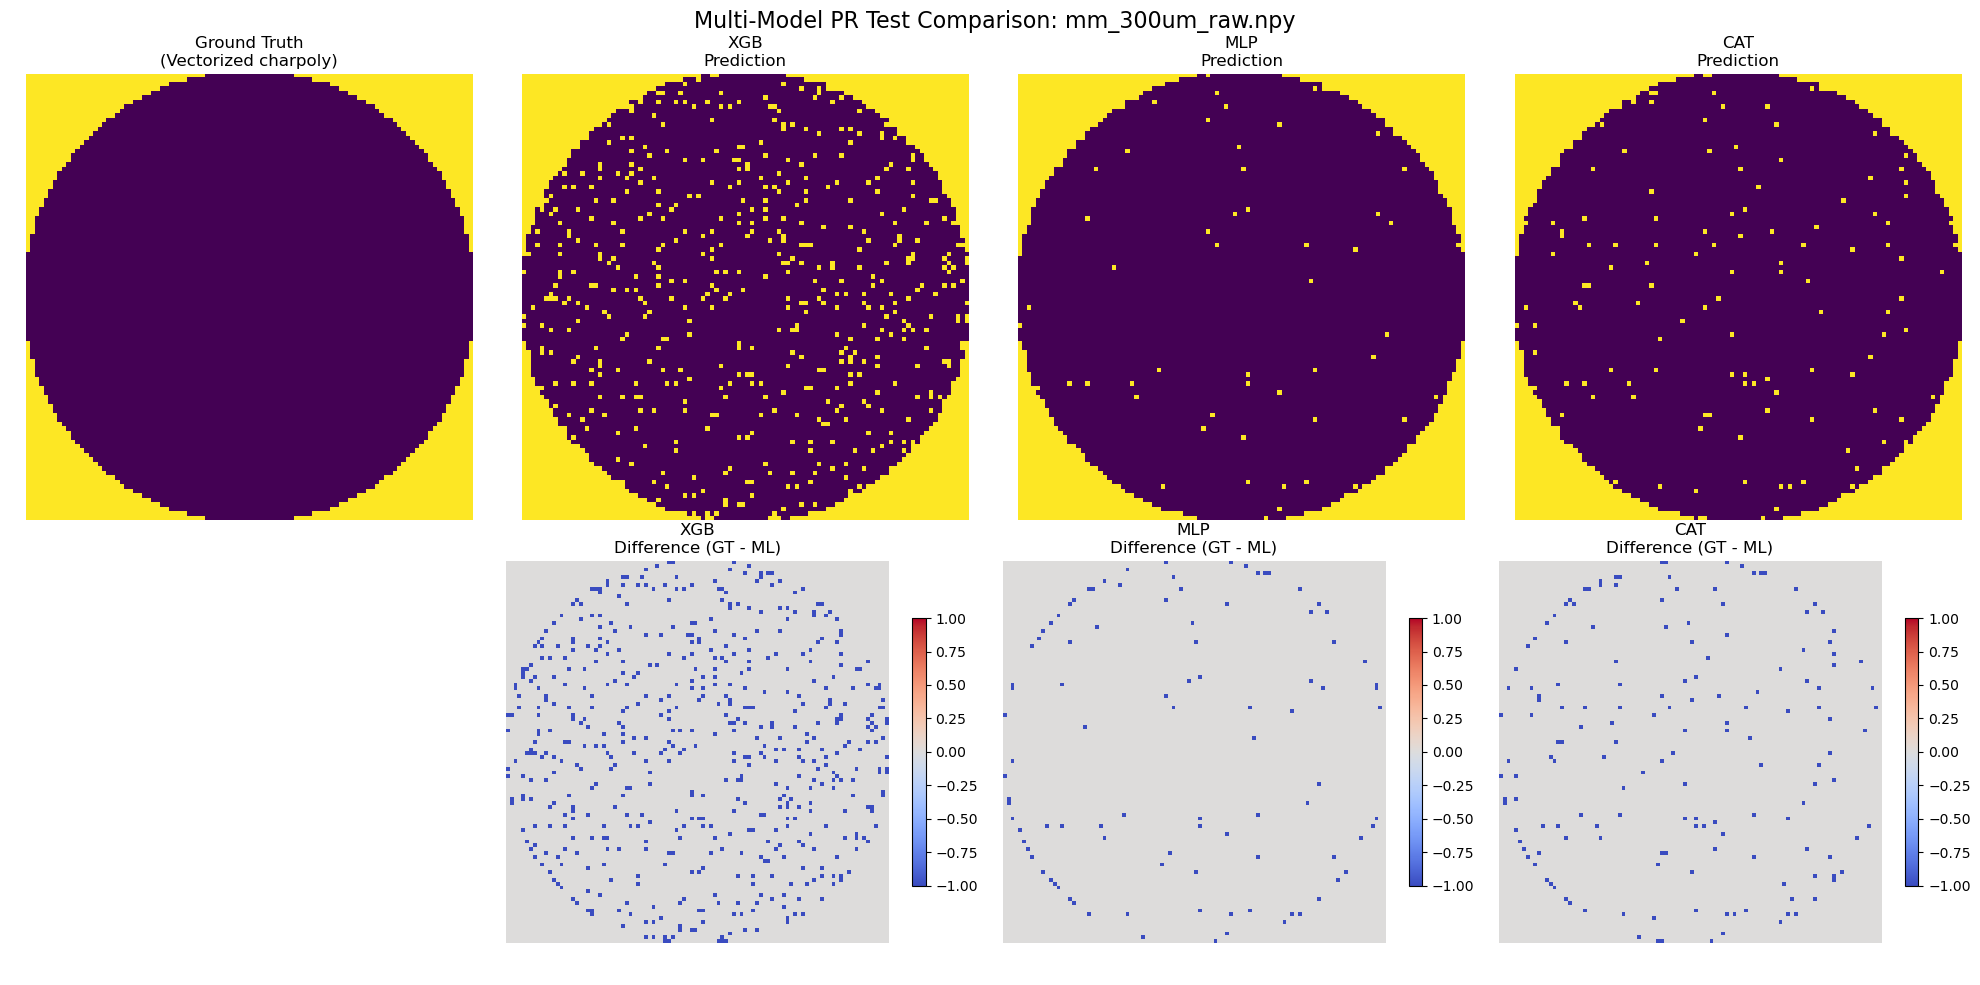


OPTIMIZED MULTI-MODEL PERFORMANCE SUMMARY
VECTORIZED Ground Truth (charpoly):
  Time: 4.61 ms (0.005s)
  Speed: 2,168,217.2 samples/s
  Speed: 2,168.22 samples/ms
  Batch Size: 100,000
  PR Pixels: 1,976

Optimized XGB:
  Time: 24.92 ms (0.025s)
  Speed: 401,353.9 samples/s
  Speed: 401.35 samples/ms
  Speed Ratio (ML/GT): 0.2x
  Time Ratio (GT/ML): 0.2x
  Batch Size: 10,000
  PR Pixels: 2,528
  Accuracy: 0.9448
  F1 Score: 0.8774
  Precision: 0.7816
  Recall: 1.0000

Optimized MLP:
  Time: 4.98 ms (0.005s)
  Speed: 2,009,192.1 samples/s
  Speed: 2,009.19 samples/ms
  Speed Ratio (ML/GT): 0.9x
  Time Ratio (GT/ML): 0.9x
  Batch Size: 100,000
  PR Pixels: 2,073
  Accuracy: 0.9903
  F1 Score: 0.9760
  Precision: 0.9532
  Recall: 1.0000

Optimized CAT:
  Time: 18.91 ms (0.019s)
  Speed: 528,755.5 samples/s
  Speed: 528.76 samples/ms
  Speed Ratio (ML/GT): 0.2x
  Time Ratio (GT/ML): 0.2x
  Batch Size: 10,000
  PR Pixels: 2,137
  Accuracy: 0.9839
  F1 Score: 0.9609
  Precision: 0.9247
  Re

In [14]:
if __name__ == "__main__":
    # Define sample configuration
    TISSUE_TYPE = 'simulated' 
    SAMPLE_NAME = 'mm_300um_raw.npy'  # Non-combined sample (H,W,16)

    print("OPTIMIZED Multi-Model Mueller Matrix Runtime Test")
    print("Comparing XGBoost, MLP, and CatBoost with ground truth PR test")
    print("Using large batch sizes for maximum performance")
    
    # Run OPTIMIZED multi-model comparison with large batch sizes
    results = run_multi_model_comparison(
        models=['xgb', 'mlp', 'cat'],
        gt_batch_size=100000,      # Large batch for ground truth
        ml_batch_size=100000,      # Large batch for MLP (XGB/Cat process full dataset)
        threshold=0.5
    )
    
    if results:
        print(f"\nOptimized multi-model comparison completed successfully!")
        print(f"Configuration used:")
        print(f"  Ground Truth Batch Size: {results['config']['gt_batch_size']:,}")
        print(f"  ML Batch Size: {results['config']['ml_batch_size']:,}")
        print(f"  Threshold: {results['config']['threshold']}")
        